# Imports

In [140]:
# System functionality
import os
import glob 

# Data Analysis
import xarray as xr
import xesmf as xe
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker

# Cartopy
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from cartopy import util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

# Auxiliary Functions
from auxiliary_functions.time_utils import convert_ns_to_datetime
from auxiliary_functions import xarray_utils

# Logging
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

# Load RMM data

In [2]:
def load_txt_as_xarray(path):
    # Read the whitespace-delimited file
    df = pd.read_csv(
        path,
        delim_whitespace=True,
        header=None,
        names=["year", "month", "day", "hour", "var1", "var2", "var3"],
        na_values=[-99.0],
    )

    # Build datetime64 index
    df["time"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

    # Set time as index
    df = df.set_index("time")

    # Drop the original date columns
    df = df.drop(columns=["year", "month", "day", "hour"])

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    return ds

# Example usage:
RMM_indices = load_txt_as_xarray("RMM.txt")
RMM1 = RMM_indices["var1"]
RMM2 = RMM_indices["var2"]
amplitude = RMM_indices["var3"]


/glade/derecho/scratch/sressel/tmp/ipykernel_99153/2543388944.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


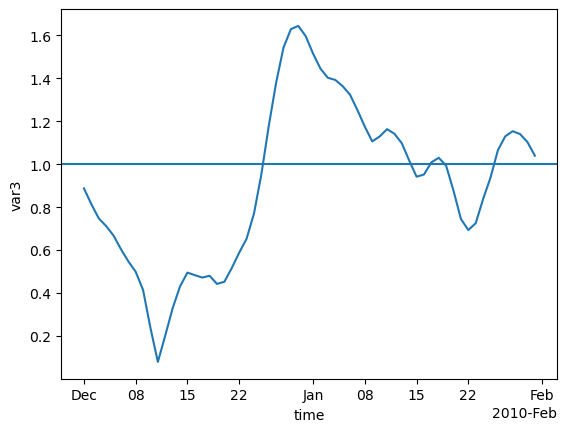

In [3]:
amplitude.sel(time=slice('2009-12-01T00:00:00.000000000', '2010-01-31T00:00:00.000000000')).plot()
plt.axhline(y=1)

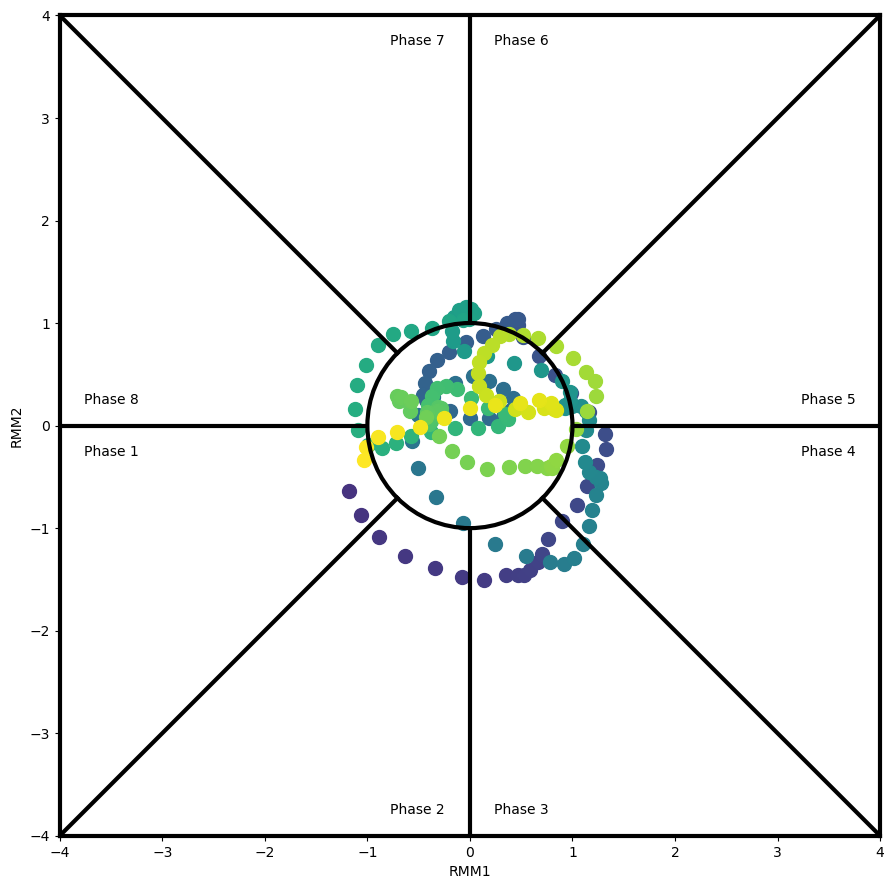

In [48]:
# plt.scatter(
#     RMM1.isel(time=slice(3371-100, 3371+100)),
#     RMM2.isel(time=slice(3371-100, 3371+100)),
# )
# plt.xlim(-4, 4)
# plt.ylim(-4, 4)
# plt.gca().set_aspect('equal')

# Configure plot
[fig, ax] = plt.subplots(figsize=(9,9))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
plt.xlabel("RMM1")
plt.ylabel("RMM2")
ax.set_facecolor("white")

# Plot index points
colormap = sns.color_palette("viridis", as_cmap=True)
start_time = '2009-10-01T00:00:00.000000000'
end_time = '2010-04-30T00:00:00.000000000'
start_index = list(amplitude.time.values).index(amplitude.sel(time=start_time).time)
end_index = list(amplitude.time.values).index(amplitude.sel(time=end_time).time)
ax.plot(RMM1[start_index], RMM2[start_index], color="black", marker=".", ls="-", ms=30)
for i in range(start_index + 1, end_index + 1):
    ax.plot(
        RMM1[i],
        RMM2[i],
        color=colormap((i - start_index) / (end_index - start_index)),
        marker="o",
        ms=10,
    )

# Add phase regions overlay
circle1 = plt.Circle((0, 0), 1.0, color="k", fill=False, lw=3, zorder=10)
ax.hlines(y=0, xmin=-4, xmax=-1, color="k", lw=3, ls="-")
ax.hlines(y=0, xmin=1, xmax=4, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=-4, ymax=-1, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=1, ymax=4, color="k", lw=3, ls="-")
ax.plot([np.sqrt(2) / 2, 4], [np.sqrt(2) / 2, 4], color="k", lw=3, ls="-")


x_vals = {
    1:-1,
    2:-1,
    3:1,
    4:1,
    5:1,
    6:1,
    7:-1,
    8:-1
}

y_val1 = {
    1:0,
    2:-4,
    3:-4,
    4:0,
    5:0,
    6:np.linspace(0,4,len(RMM1)),
    7:np.linspace(0,4,len(RMM1)),
    8:0
}

y_val2 = {
    1:-1*np.linspace(0, 4, len(RMM1)),
    2:-1*np.linspace(0, 4, len(RMM1)),
    3:-1*np.linspace(0, 4, len(RMM1)),
    4:-1*np.linspace(0, 4, len(RMM1)),
    5:1*np.linspace(0, 4, len(RMM1)),
    6:4,
    7:4,
    8:1*np.linspace(0, 4, len(RMM1))
}

# Fill one of the phases in with blue
# val=2
# ax.fill_between(
#     x_vals[val]*np.linspace(0, 4, len(RMM1)), 
#     y_val1[val], 
#     y_val2[val]
# )

# x = np.linspace(-1,1,100)
# ax.fill_between(x, -np.sqrt(1-x**2), np.sqrt(1-x**2), color='white')

# Add lines to differentiate the phases
ax.plot([np.sqrt(2) / 2, 4], [-np.sqrt(2) / 2, -4], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [4, np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [-4, -np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.add_patch(circle1)

# Add phase labels
ax.text(-3.5, -0.26, f'Phase 1',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, -3.75, f'Phase 2', horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, -3.75, f'Phase 3',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, -0.26, f'Phase 4',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, 0.25, f'Phase 5',    horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, 3.75, f'Phase 6',    horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, 3.75, f'Phase 7',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-3.5, 0.25, f'Phase 8',   horizontalalignment='center',
     verticalalignment='center')

# Add MJO-location labels
# ax.text(0, 3.5, f'Western Pacific',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(-3.3, 0, f'Western Hemisphere \n & Africa',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(3.3, 0, f'Maritime Continent',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(0, -3.5, f'Indian Ocean',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

ax.set_aspect("equal")
plt.tight_layout()

plt.show()

# Process ERA5 data

# Load Graphcast sample data

In [53]:
gc_data = xr.open_dataset("/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/data/era5_sample.nc")
gc_data

<xarray.Dataset> Size: 307MB
Dimensions:                       (lon: 360, lat: 181, time: 14, level: 13,
                                   batch: 1)
Coordinates:
  * lon                           (lon) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * lat                           (lat) float32 724B -90.0 -89.0 ... 89.0 90.0
  * time                          (time) timedelta64[ns] 112B 0 days 00:00:00...
  * level                         (level) int32 52B 50 100 150 ... 850 925 1000
    datetime                      (batch, time) datetime64[ns] 112B ...
Dimensions without coordinates: batch
Data variables: (12/14)
    geopotential_at_surface       (lat, lon) float32 261kB ...
    land_sea_mask                 (lat, lon) float32 261kB ...
    2m_temperature                (batch, time, lat, lon) float32 4MB ...
    mean_sea_level_pressure       (batch, time, lat, lon) float32 4MB ...
    10m_v_component_of_wind       (batch, time, lat, lon) float32 4MB ...
    10m_u_component_of_wind       (batch, time, lat, lon) float32 4MB ...
    ...                            ...
    temperature                   (batch, time, level, lat, lon) float32 47MB ...
    geopotential                  (batch, time, level, lat, lon) float32 47MB ...
    u_component_of_wind           (batch, time, level, lat, lon) float32 47MB ...
    v_component_of_wind           (batch, time, level, lat, lon) float32 47MB ...
    vertical_velocity             (batch, time, level, lat, lon) float32 47MB ...
    specific_humidity             (batch, time, level, lat, lon) float32 47MB ...

# Analyze optimized data

In [9]:
data_directory = "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/200912_201001"
files_list = glob.glob(f"{data_directory}/*.nc")
# 20091201_20100131_
for file in files_list:
    data_name = file.split("/")[-1].split("20091201_20100131_")[-1]
    print(data_name)
    os.system(f"mv {file} {data_name}")

geopotential.nc
toa_incident_solar_radiation.nc
mean_sea_level_pressure_batch.nc
2m_temperature_batch.nc
era5_data.nc
specific_humidity.nc
temperature_test.nc
specific_humidity_test.nc
total_precipitation_6hr.nc
era5_data_batch.nc


mv: error writing 'era5_data_batch.nc': Disk quota exceeded
mv: error writing '201001_toa_incident_solar_radiation.nc': Disk quota exceeded


201001_toa_incident_solar_radiation.nc
vertical_velocity.nc


mv: error writing 'vertical_velocity.nc': Disk quota exceeded
mv: error writing 'vertical_velocity_test.nc': Disk quota exceeded


vertical_velocity_test.nc
10m_v_component_of_wind_batch.nc


...

mv: error writing 'u_component_of_wind_test.nc': Disk quota exceeded
mv: error writing 'v_component_of_wind_test.nc': Disk quota exceeded


mean_sea_level_pressure.nc
200912_total_precipitation.nc


mv: error writing 'mean_sea_level_pressure.nc': Disk quota exceeded


vertical_velocity_batch.nc


mv: error writing '200912_total_precipitation.nc': Disk quota exceeded
mv: error writing 'vertical_velocity_batch.nc': Disk quota exceeded


In [10]:
import xarray as xr
input_data = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/199208_199211/era5_data.nc")

In [22]:
optimized_data_array = xr.zeros_like(input_data.isel(time=0, drop=True))
optimized_data = np.load("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_params/2009-12-26T00/2009-12-26T00_96_40.npz")

In [23]:
# Assign variables with inferred dims
for key in [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    # 'day_progress_cos',
    # 'day_progress_sin',
    'geopotential',
    'geopotential_at_surface',
    'land_sea_mask',
    'mean_sea_level_pressure',
    'specific_humidity',
    'temperature',
    'toa_incident_solar_radiation',
    'total_precipitation_6hr',
    'u_component_of_wind',
    'v_component_of_wind',
    'vertical_velocity'
]:

    arr = optimized_data[key]

    if arr.ndim == 2:
        optimized_data_array[key] = (("lat", "lon"), arr)

    elif arr.ndim == 3:
        optimized_data_array[key] = (("time", "lat", "lon"), arr)

    elif arr.ndim == 4:
        optimized_data_array[key] = (("batch", "time", "lat", "lon"), arr)

    elif arr.ndim == 5:
        optimized_data_array[key] = (("batch", "time", "level", "lat", "lon"), arr)

    else:
        raise ValueError(f"Don't know how to assign dims for {key} with shape {arr.shape}")

In [9]:
def datetime_to_ns(initial_time, final_time):
    return (final_time.astype("timedelta64[ns]") - initial_time.astype("timedelta64[ns]")).astype("timedelta64[ns]")

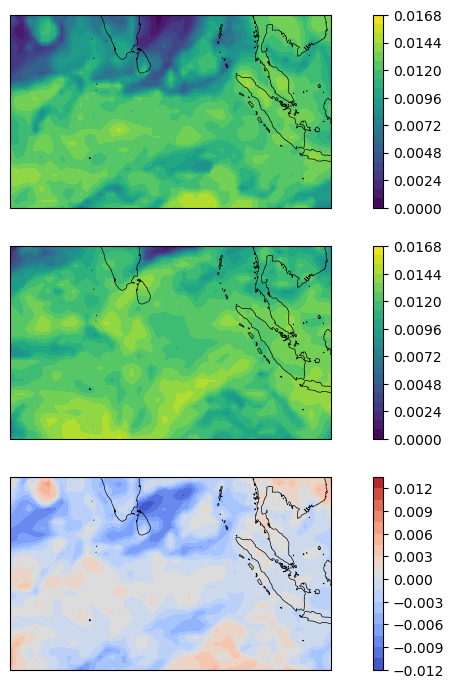

In [24]:
start_date = '2009-12-01T00:00:00.000000000'
end_date = '2010-01-31T00:00:00.000000000'

optimized_day = datetime_to_ns(
    np.datetime64(start_date), np.datetime64('2009-12-26T00:00:00.000000000')
)
level_to_plot = 850
variable_to_plot = 'specific_humidity'

# [fig, ax] = plt.subplots(3, 1, figsize=(12,16))

fig, ax = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(11,8.5))

i  =0
c_opt = ax[0].contourf(
    optimized_data_array[variable_to_plot].lon,
    optimized_data_array[variable_to_plot].lat,
    optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = 21
)
fig.colorbar(c_opt, ax=ax[0])
ax[0].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_init = ax[1].contourf(
    input_data.lon,
    input_data.lat,
    input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0),
    levels = c_opt.levels
)
fig.colorbar(c_init, ax=ax[1])
ax[1].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_diff = ax[2].contourf(
    input_data.lon,
    input_data.lat,
    (optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(time=i, batch=0) - input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0)),
    # levels = np.linspace(-0.01, 0.01, 21),
    levels=21,
    cmap = 'coolwarm'
)
fig.colorbar(c_diff, ax=ax[2])
ax[2].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

# for axis in ax:
#     rect = patches.Rectangle(
#         (70, -10),        # lower-left corner
#         30, 20,   # rectangle size
#         linewidth=1.5,
#         edgecolor='red',
#         facecolor='none',   # or a color like 'lightgray'
#         alpha=0.5
#     )

#     axis.add_patch(rect)

for axis in ax:
    axis.set_xlim(60, 110)
    axis.set_ylim(-15, 15)

plt.show()

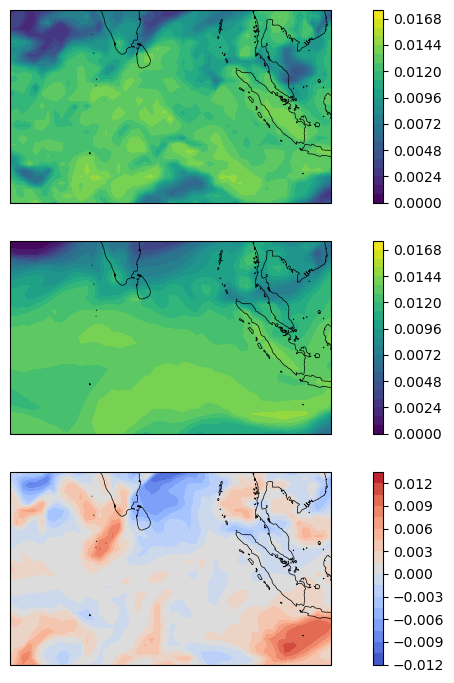

In [ ]:
# pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/2009-12-26T00/2009-12-26T00_40.zarr")
pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/1992-08-11T00/1992-08-11T00_120.zarr")

start_date = '1992-08-11T00:00:00.000000000'
end_date = '1992-11-12T00:00:00.000000000'

# optimized_day = datetime_to_ns(
#     np.datetime64(start_date), np.datetime64('2009-12-26T00:00:00.000000000')
# )
level_to_plot = 850
variable_to_plot = 'specific_humidity'

# [fig, ax] = plt.subplots(3, 1, figsize=(12,16))

fig, ax = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(11,8.5))

i=-1
c_input = ax[0].contourf(
    input_data[variable_to_plot].lon,
    input_data[variable_to_plot].lat,
    input_data[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = 21
)
fig.colorbar(c_input, ax=ax[0])
ax[0].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_pred = ax[1].contourf(
    pred_data.lon,
    pred_data.lat,
    pred_data[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = c_input.levels
)
fig.colorbar(c_pred, ax=ax[1])
ax[1].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_diff = ax[2].contourf(
    input_data.lon,
    input_data.lat,
    (pred_data[variable_to_plot] - input_data[variable_to_plot]).sel(level=level_to_plot).isel(batch=0, time=i),
    # levels = np.linspace(-0.01, 0.01, 21),
    levels=21,
    cmap = 'coolwarm'
)
fig.colorbar(c_diff, ax=ax[2])
ax[2].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

for axis in ax:
    axis.set_xlim(60, 110)
    axis.set_ylim(-15, 15)

# for axis in ax:
#     rect = patches.Rectangle(
#         (70, -10),        # lower-left corner
#         30, 20,   # rectangle size
#         linewidth=1.5,
#         edgecolor='red',
#         facecolor='none',   # or a color like 'lightgray'
#         alpha=0.5
#     )

#     axis.add_patch(rect)
plt.show()

# Analyze predicted data

In [203]:
era5_data = xr.load_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/199208_199211/era5_data.nc").load()
era5_data = convert_ns_to_datetime(era5_data, '1992-08-01').swap_dims({'time':'datetime'})
pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/1992-08-11T00/1992-08-11T00_120.zarr").load()
# pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/1992-08-14T00/1992-08-14T00_364.zarr")
pred_data = convert_ns_to_datetime(pred_data, "1992-08-10T18").swap_dims({'time':'datetime'})

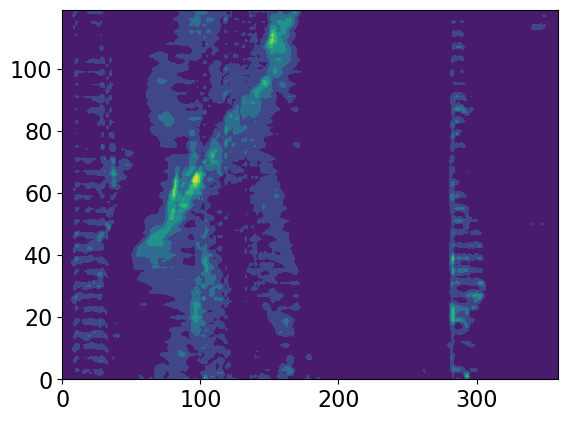

In [165]:
plt.contourf(pred_data['total_precipitation_6hr'].isel(batch=0).sel(lat=slice(-5,5)).mean(dim='lat'))

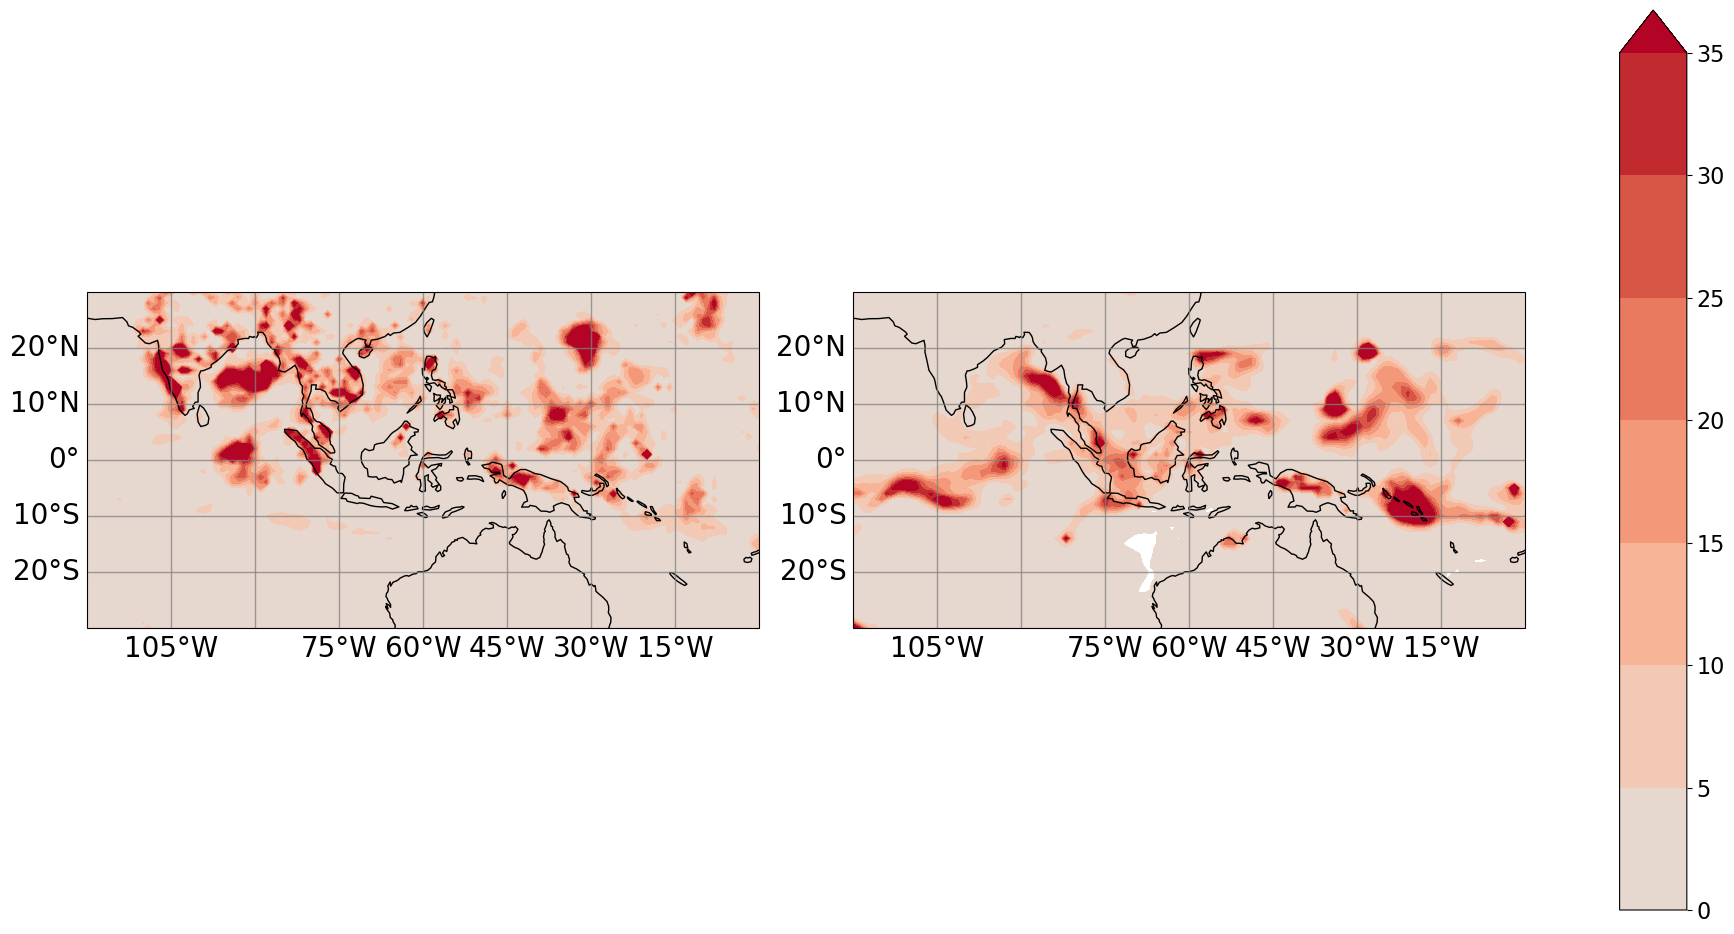

In [204]:
variable_to_plot = 'total_precipitation_6hr'
time_to_plot = "1992-08-11T06"

plt.rcParams.update({'font.size':16})
fig = plt.figure(figsize=(16,9))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 10])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.2)

central_longitude = -180
proj = ccrs.PlateCarree(central_longitude=central_longitude)
data_crs = ccrs.PlateCarree()
coastline_width = 1


ax = [
    fig.add_subplot(gs[0], projection=proj),
    fig.add_subplot(gs[1], projection=proj),
]
cbar_ax = fig.add_subplot(gs[2])

# cdata_era5 = xarray_utils.add_cyclic_point(
#     4000*era5_data['total_precipitation_6hr'],
#     dim='lon'
# ).isel(batch=0).sel(lat=slice(-30, 30), lon=slice(60, 180), datetime="1992-08-14T06"),

# cdata_pred = xarray_utils.add_cyclic_point(
#     4000*pred_data['total_precipitation_6hr'],
#     dim='lon'
# ).isel(batch=0).sel(lat=slice(-30, 30), lon=slice(60, 180), datetime="1992-08-14T06"),

im = ax[0].contourf(
    era5_data.lon,
    era5_data.lat,
    (4000*era5_data[variable_to_plot]).isel(batch=0).sel(datetime=time_to_plot),
    levels=np.arange(0, 40, 5), 
    # levels=np.linspace(-21, 21, 21),
    transform=data_crs,
    cmap='coolwarm', 
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='max'
)

ax[1].contourf(
    pred_data.lon,
    pred_data.lat,
    (4000*pred_data[variable_to_plot]).isel(batch=0).sel(datetime=time_to_plot),
    # levels=np.arange(0, 27.5, 2.5), 
    levels=im.levels, 
    transform=data_crs,
    cmap='coolwarm', 
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='max'
)

# Add colorbar
cbar = fig.colorbar(im, cax=cbar_ax)

for axis in ax:
    axis.add_feature(cfeature.COASTLINE, lw=coastline_width)
    axis.set_xlim(central_longitude+60, central_longitude+180)
    axis.set_ylim(-30, 30)
    gl = axis.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15
    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(central_longitude+np.arange(60,210,15))
    # gl.xlocator = LongitudeLocator(30)
    gl.xformatter = LongitudeFormatter()
    gl.xlabel_style = {'fontsize':20}
    gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
    gl.yformatter = LatitudeFormatter()
    gl.ylabel_style = {'fontsize':20}

plt.show()

In [100]:
meridional_mean_graphcast_precip = pred_data['total_precipitation_6hr'].sel(lat=slice(-15,15)).mean(dim='lat')
meridional_mean_era5_precip = era5_data['total_precipitation_6hr'].sel(lat=slice(-15,15)).mean(dim='lat')

In [46]:
print(4000*meridional_mean_graphcast_precip.isel(batch=0).min().values, 4000*meridional_mean_graphcast_precip.isel(batch=0).max().values)

0.08542740529678254 55.12412197210572


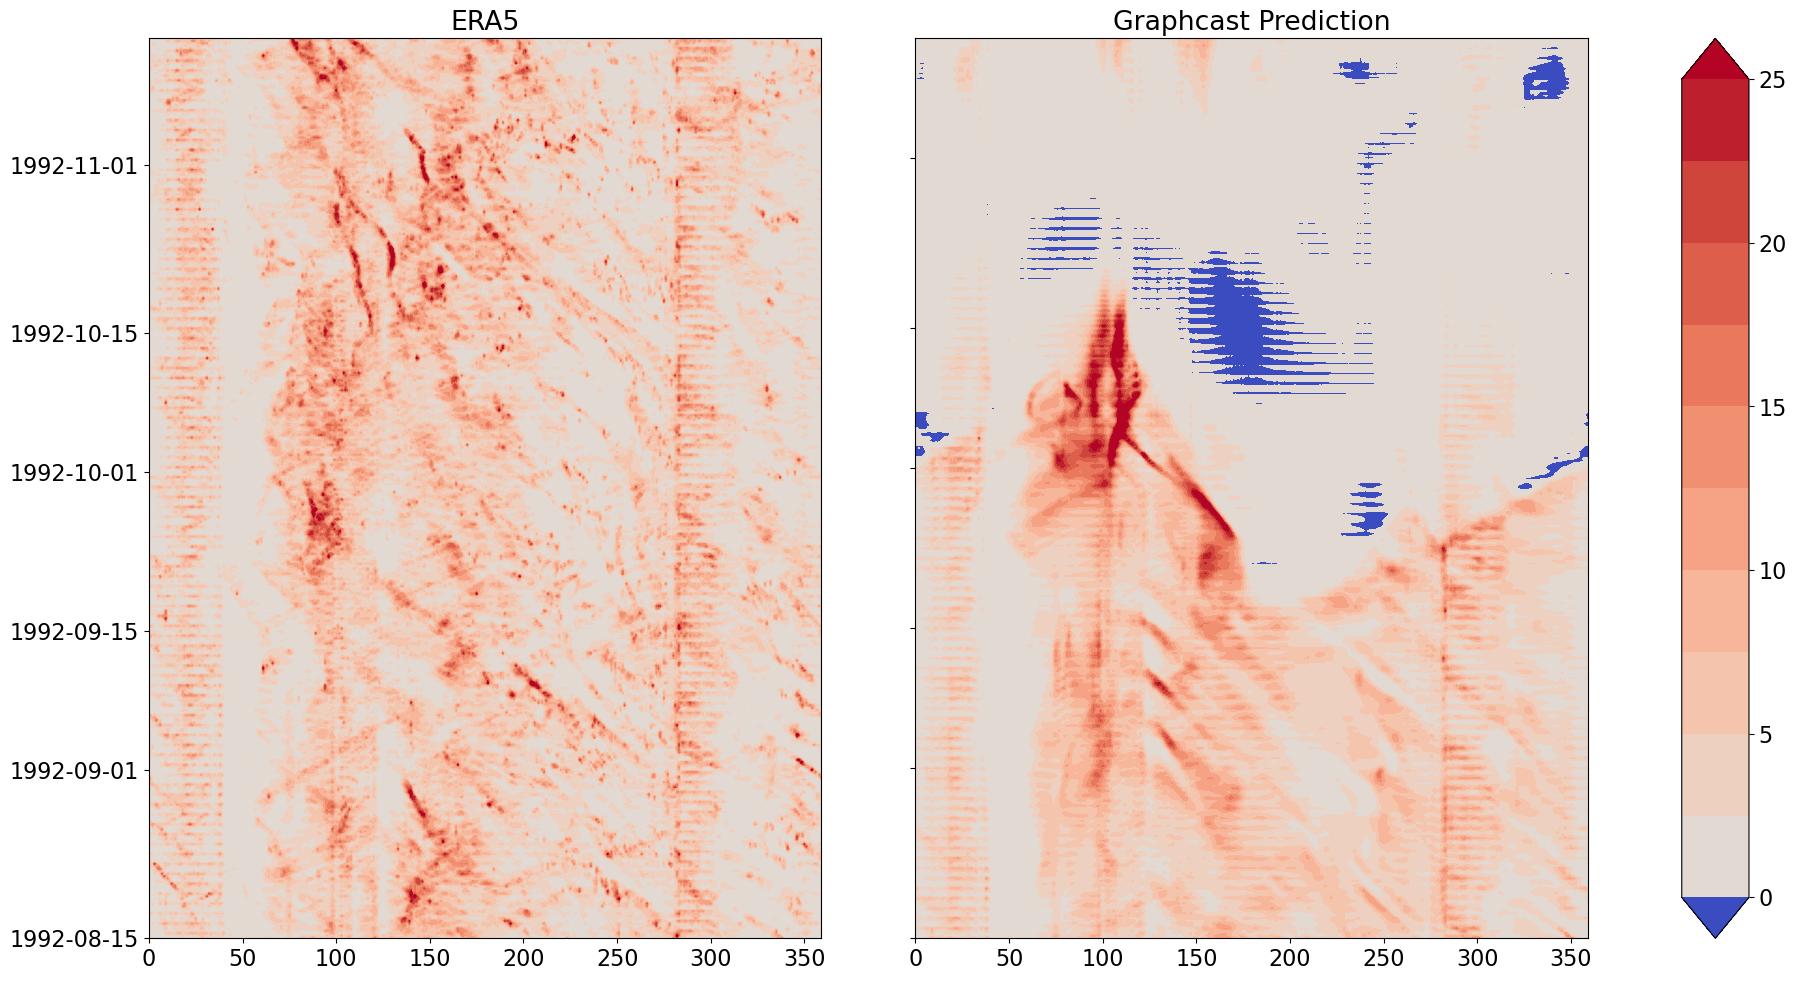

In [118]:
plt.rcParams.update({'font.size':16})
fig = plt.figure(figsize=(16,9))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 10])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.2)

ax = [
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
]

plotting_dates = slice(
    "1992-08-15",
    "1992-11-13"
)

ax[0].set_title('ERA5')
ax[0].contourf(
    meridional_mean_era5_precip.lon,
    meridional_mean_era5_precip.datetime.sel(datetime=plotting_dates),
    4000*meridional_mean_era5_precip.isel(batch=0).sel(datetime=plotting_dates),
    levels=np.arange(0, 27.5, 2.5),
    extend='both',
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)

ax[1].set_title('Graphcast Prediction')
im = ax[1].contourf(
    meridional_mean_graphcast_precip.lon,
    meridional_mean_graphcast_precip.datetime.sel(datetime=plotting_dates),
    4000*meridional_mean_graphcast_precip.isel(batch=0).sel(datetime=plotting_dates),
    levels=np.arange(0, 27.5, 2.5),
    extend='both',
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)

ax[1].set_yticklabels('')

fig.colorbar(im, cax=ax[-1])

plt.show()

<xarray.DataArray 'total_precipitation_6hr' (batch: 1, datetime: 488, lat: 181,
                                             lon: 360)> Size: 127MB
array([[[[4.76837158e-06, 4.76837158e-06, 4.76837158e-06, ...,
          4.76837158e-06, 4.76837158e-06, 4.76837158e-06],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.42574310e-04, 1.39713287e-04, 1.36852264e-04, ...,
          1.55448914e-04, 1.52111053e-04, 1.46865845e-04],
         [2.07424164e-04, 2.04086304e-04, 2.01702118e-04, ...,
          1.97887421e-04, 2.01225281e-04, 2.04086304e-04],
         [2.61783600e-04, 2.61783600e-04, 2.61783600e-04, ...,
          2.61783600e-04, 2.61783600e-04, 2.61783600e-04]],

        [[1.43051147e-06, 1.43051147e-06, 1.43051147e-06, ...,
          1.43051147e-06, 1.43051147e-06, 1.43051147e-06],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          6.43730164e-05, 7.15255737e-05, 7.86781311e-05],
         [5.72204590e-05, 6.00814819e-05, 6.29425049e-05, ...,
          4.57763672e-05, 4.91142273e-05, 5.24520874e-05],
         [2.71797180e-05, 2.71797180e-05, 2.71797180e-05, ...,
          2.71797180e-05, 2.71797180e-05, 2.71797180e-05]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.29699707e-04, 1.35898590e-04, 1.43051147e-04, ...,
          1.17301941e-04, 1.21593475e-04, 1.25885010e-04],
         [1.83582306e-04, 1.90258026e-04, 1.97410583e-04, ...,
          1.69277191e-04, 1.73568726e-04, 1.79290771e-04],
         [1.80244446e-04, 1.80244446e-04, 1.80244446e-04, ...,
          1.80244446e-04, 1.80244446e-04, 1.80244446e-04]]]],
      dtype=float32)
Coordinates:
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * datetime  (datetime) datetime64[ns] 4kB 1992-08-01 ... 1992-11-30T18:00:00
    time      (datetime) timedelta64[ns] 4kB 0 days 00:00:00 ... 121 days 18:...
    number    int64 8B 0
    expver    (datetime) <U4 8kB '0001' '0001' '0001' ... '0001' '0001' '0001'
Dimensions without coordinates: batch
Attributes:
    regrid_method:  bilinear

In [19]:
meridional_mean_era5_precip.isel(batch=0)

<xarray.DataArray 'total_precipitation_6hr' (time: 488, lon: 360)> Size: 703kB
array([[1.01002777e-04, 1.43181198e-04, 1.56836075e-04, ...,
        1.96630310e-04, 1.27315521e-04, 9.95289229e-05],
       [7.94150619e-05, 1.15871429e-04, 1.10842964e-04, ...,
        1.92858963e-04, 1.25018036e-04, 8.19726411e-05],
       [2.52290210e-05, 3.24249268e-05, 4.34355316e-05, ...,
        7.16122740e-05, 1.18212265e-04, 2.82200908e-05],
       ...,
       [1.90084626e-04, 1.83972443e-04, 1.57009476e-04, ...,
        2.77475890e-04, 2.25153839e-04, 1.32604080e-04],
       [7.45599900e-05, 8.26662217e-05, 1.19859520e-04, ...,
        7.26959915e-05, 6.48065034e-05, 5.43594360e-05],
       [3.64000152e-04, 2.51379883e-04, 1.28052445e-04, ...,
        2.18261368e-04, 2.97416351e-04, 3.23772430e-04]], dtype=float32)
Coordinates:
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (time) datetime64[ns] 4kB 1992-08-01 ... 1992-11-30T18:00:00
  * time      (time) timedelta64[ns] 4kB 0 days 00:00:00 ... 121 days 18:00:00
    number    int64 8B 0
    expver    (time) <U4 8kB '0001' '0001' '0001' ... '0001' '0001' '0001'

In [38]:
optimized_data.files

['10m_u_component_of_wind',
 '10m_v_component_of_wind',
 '2m_temperature',
 'day_progress_cos',
 'day_progress_sin',
 'geopotential',
 'geopotential_at_surface',
 'land_sea_mask',
 'mean_sea_level_pressure',
 'specific_humidity',
 'temperature',
 'toa_incident_solar_radiation',
 'total_precipitation_6hr',
 'u_component_of_wind',
 'v_component_of_wind',
 'vertical_velocity',
 'year_progress_cos',
 'year_progress_sin']